# Fender Curve Mapping — Swell Conditions

Swell analogue of `05_FenderCurveMapping.ipynb`. For every heading and swell $H_s$/$T_p$
condition, find each fender's dynamic-max force (post-transient) and plot where on the
fender spring curve that maximum falls.

The swell HDF5 files store only `TotalForce_FenderX` (no `Deformation_FenderX`), so the
deformation is recovered by intersecting the max force with the piecewise spring curve
(same fallback as notebook 05).

Headings: 0°, 45°, 90°, 135°, 180°.

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

HEADINGS       = ['0deg', '45deg', '90deg', '135deg', '180deg']
HEADING_LABELS = {'0deg': '0°', '45deg': '45°', '90deg': '90°',
                  '135deg': '135°', '180deg': '180°'}
# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR   = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
import sys
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, save
apply()
print(f'Working directory: {Path.cwd()}')

# Fender spring curve (from SIMA input table) — identical to notebook 05
CURVE_DIST_M   = np.array([0.0, -0.25, -0.5, -0.75, -0.95, -1.05, -1.25, -1.5,
                             -1.75, -1.95, -2.05, -2.25, -2.5])
CURVE_FORCE_KN = np.array([0.0, 818.18, 1242.4, 1393.9, 1272.0, 1272.0,
                             1620.5, 2000.0, 1930.3, 1808.3, 1808.3,
                             2822.7, 5053.0])
CURVE_DIST_POS = np.abs(CURVE_DIST_M)

FENDER_ELEMS   = [f'Fender{i}' for i in range(1, 7)]
FENDER_MARKERS = ['o', 's', '^', 'D', 'v', 'P']


def find_curve_intersections(force_kN):
    """Return list of deformation values [m] where curve == force_kN."""
    pts = []
    for i in range(len(CURVE_FORCE_KN) - 1):
        f0, f1 = CURVE_FORCE_KN[i], CURVE_FORCE_KN[i + 1]
        d0, d1 = CURVE_DIST_M[i], CURVE_DIST_M[i + 1]
        if f0 == f1:
            continue
        flo, fhi = min(f0, f1), max(f0, f1)
        if flo <= force_kN <= fhi:
            t = (force_kN - f0) / (f1 - f0)
            pts.append(d0 + t * (d1 - d0))
    return pts

In [2]:
# Swell Hs/Tp grid (matches 07_DAF_Swells.ipynb) and transient cut
TRANSIENT_S   = 400
DT            = 0.5
TRANSIENT_IDX = int(TRANSIENT_S / DT)   # post-transient window, consistent with notebook 07

HS_VALS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
TP_VALS = list(range(8, 21))

cases = pd.DataFrame(
    [(hs, tp) for hs in HS_VALS for tp in TP_VALS],
    columns=['Hs', 'Tp']
)
cases.insert(0, 'condition', cases.index + 1)

SWELL_DYNAMIC = '{h}/Swells/DynamicResults_swells.h5'
print(f'{len(cases)} swell conditions per heading')

78 swell conditions per heading


In [3]:
rows = []

for heading in HEADINGS:
    dyn_path = NOTEBOOK_DIR / SWELL_DYNAMIC.format(h=heading)
    if not dyn_path.exists():
        print(f'  {heading}: file not found — skipped')
        continue

    with h5py.File(dyn_path, 'r') as fd:
        root = list(fd.keys())[0]
        sw_d = fd[root]['Swells']
        keys = sorted(sw_d.keys(), key=lambda x: int(x.rsplit('_', 1)[-1]))
        for k in keys:
            n = int(k.rsplit('_', 1)[-1])
            try:
                grp = sw_d[k]['Dynamic']['Tanker']['Positioning system force']
            except KeyError:
                continue
            hs = cases.loc[cases.condition == n, 'Hs']
            tp = cases.loc[cases.condition == n, 'Tp']
            hs = float(hs.iloc[0]) if len(hs) else np.nan
            tp = float(tp.iloc[0]) if len(tp) else np.nan
            for i, fdr in enumerate(FENDER_ELEMS):
                ts    = grp[f'TotalForce_{fdr}'][TRANSIENT_IDX:]
                f_max = float(np.max(ts))
                rows.append({
                    'heading':      heading,
                    'cond_num':     n,
                    'Hs':           hs,
                    'Tp':           tp,
                    'fender':       fdr,
                    'fender_idx':   i,
                    'max_force_kN': f_max / 1e3,
                    'defm_m':       np.nan,   # no Deformation_Fender stored for swells
                })
    print(f'  {heading}: OK')

df = pd.DataFrame(rows)
print(f'\nTotal rows: {len(df)}')
print(df.head(12).to_string())

  0deg: OK
  45deg: OK
  90deg: OK
  135deg: OK
  180deg: OK

Total rows: 2340
   heading  cond_num   Hs   Tp   fender  fender_idx  max_force_kN  defm_m
0     0deg         1  0.1  8.0  Fender1           0    144.176849     NaN
1     0deg         1  0.1  8.0  Fender2           1    141.701828     NaN
2     0deg         1  0.1  8.0  Fender3           2    139.295273     NaN
3     0deg         1  0.1  8.0  Fender4           3    136.826096     NaN
4     0deg         1  0.1  8.0  Fender5           4    134.540131     NaN
5     0deg         1  0.1  8.0  Fender6           5    131.983200     NaN
6     0deg         2  0.1  9.0  Fender1           0    144.522797     NaN
7     0deg         2  0.1  9.0  Fender2           1    141.365631     NaN
8     0deg         2  0.1  9.0  Fender3           2    138.776627     NaN
9     0deg         2  0.1  9.0  Fender4           3    136.034088     NaN
10    0deg         2  0.1  9.0  Fender5           4    133.363541     NaN
11    0deg         2  0.1  9.0  F

## Fender Spring Curve — Dynamic Max per Swell Condition

One figure per heading (all 78 swell conditions). To reduce clutter, only the **governing fender**
(the one carrying the maximum force) per condition is shown; colour = $H_s$, marker shape = fender.
Deformation is read off the spring curve via force intersection (no stored deformation).

The tabulated curve ends at 2.5 m / 5053 kN — full compression, i.e. **fender bottoming**.
The fender cannot deflect any further, so a larger max force is plotted on a **vertical line at
2.5 m** (force rises, deformation fixed) rather than along an extrapolated curve. These points
(ringed in red) mark a limitation of the study: at these sea states the fenders are too weak and
bottom out.

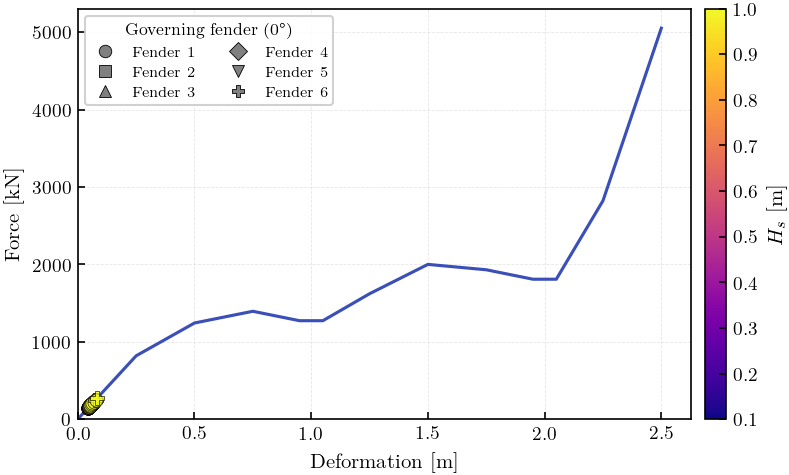

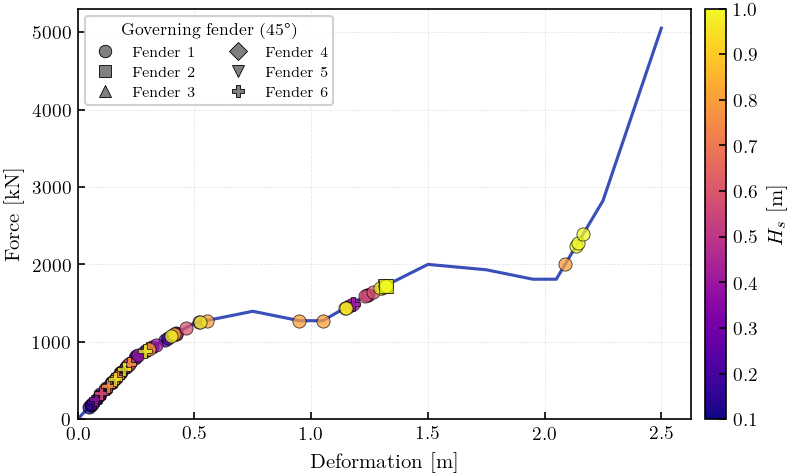

90deg: 2 bottomed point(s) above 5053 kN (max 6977 kN) — plotted vertically at 2.5 m


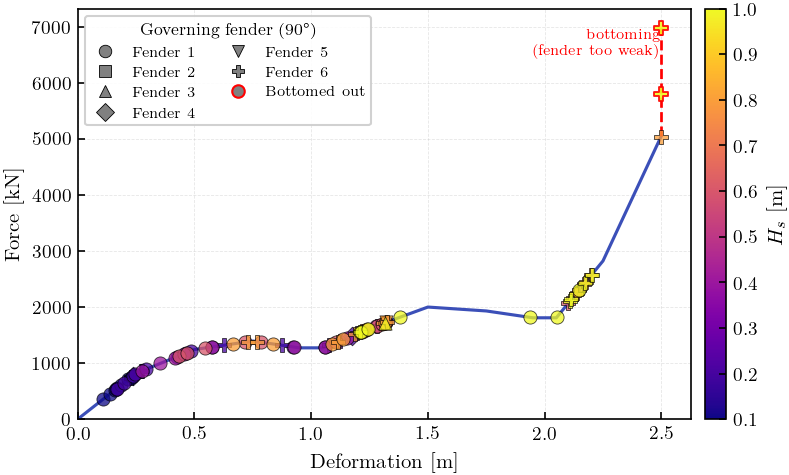

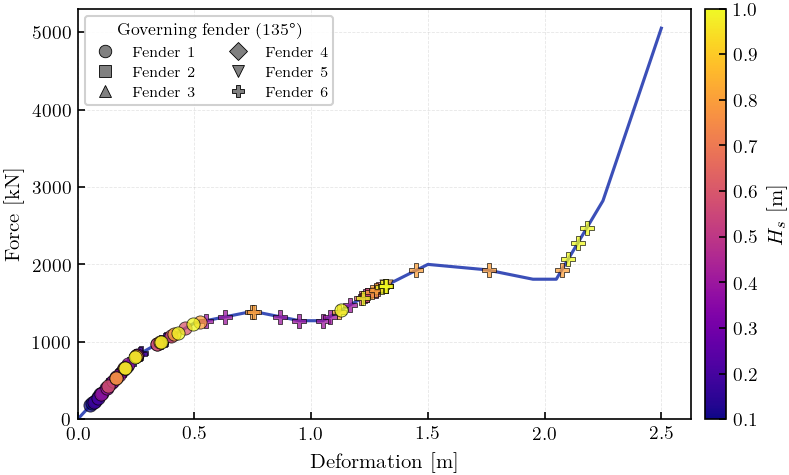

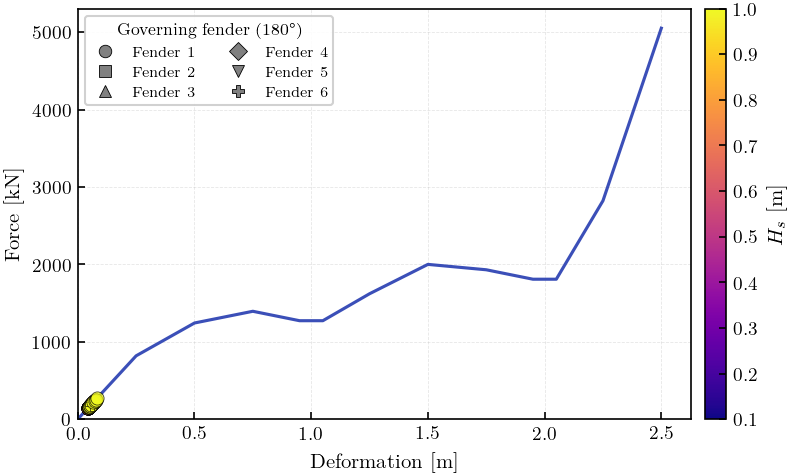

In [4]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

CMAP = plt.cm.plasma
norm = Normalize(vmin=min(HS_VALS), vmax=max(HS_VALS))

# Bottoming: tabulated curve ends at 2.5 m / 5053 kN (full compression). The fender cannot
# deflect further, so a larger max force is shown on a vertical line at 2.5 m — deformation is
# capped, force rises. These points flag a study limitation (fenders too weak, they bottom out).
F_MAX_CURVE = CURVE_FORCE_KN[-1]
D_BOTTOM    = CURVE_DIST_POS[-1]

fender_handles = [
    Line2D([0], [0], marker=FENDER_MARKERS[i], color='w',
           markerfacecolor='gray', markeredgecolor='k',
           markeredgewidth=0.4, markersize=6,
           label=f'Fender {i + 1}')
    for i in range(6)
]

# Only the governing (max-force) fender per swell condition is plotted, to reduce clutter.
for heading in HEADINGS:
    sub = df[df.heading == heading]
    if sub.empty:
        continue

    gov = sub.loc[sub.groupby('cond_num')['max_force_kN'].idxmax()]

    fig, ax = plt.subplots(figsize=full())
    ax.plot(CURVE_DIST_POS, CURVE_FORCE_KN, color='#3B4FB8', lw=1.5, zorder=2)

    n_bottom     = 0
    f_bottom_max = F_MAX_CURVE
    for _, row in gov.iterrows():
        f_kN  = row['max_force_kN']
        fi    = int(row['fender_idx'])
        color = CMAP(norm(row['Hs']))
        inter = find_curve_intersections(f_kN)
        if inter:
            for d_int in inter:
                ax.scatter(-d_int, f_kN, color=color,
                           marker=FENDER_MARKERS[fi], s=40,
                           alpha=0.75, linewidths=0.4,
                           edgecolors='k', zorder=5)
        elif f_kN > F_MAX_CURVE:
            # fender bottomed out — deformation fixed at 2.5 m, plot straight up, ring in red
            ax.scatter(D_BOTTOM, f_kN, color=color,
                       marker=FENDER_MARKERS[fi], s=44,
                       alpha=0.9, linewidths=0.9,
                       edgecolors='red', zorder=6)
            n_bottom    += 1
            f_bottom_max = max(f_bottom_max, f_kN)

    # vertical bottoming branch at 2.5 m: force rises, deformation can't grow
    if n_bottom:
        ax.plot([D_BOTTOM, D_BOTTOM], [F_MAX_CURVE, f_bottom_max],
                color='red', lw=1.3, ls='--', zorder=3)
        ax.text(D_BOTTOM, f_bottom_max, ' bottoming\n (fender too weak)',
                va='top', ha='right', fontsize=7, color='red')

    ax.set_xlabel('Deformation [m]', fontsize=10)
    ax.set_ylabel('Force [kN]', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

    sm = ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.02)
    cb.set_label('$H_s$ [m]')

    handles = list(fender_handles)
    if n_bottom:
        handles.append(Line2D([0], [0], marker='o', color='w',
                              markerfacecolor='gray', markeredgecolor='red',
                              markeredgewidth=1.0, markersize=6,
                              label='Bottomed out'))
    ax.legend(handles=handles, fontsize=7, ncol=2,
              loc='upper left', title=f'Governing fender  ({HEADING_LABELS[heading]})',
              title_fontsize=8, framealpha=0.9)

    if n_bottom:
        print(f'{heading}: {n_bottom} bottomed point(s) above {F_MAX_CURVE:.0f} kN '
              f'(max {f_bottom_max:.0f} kN) — plotted vertically at 2.5 m')

    plt.tight_layout()
    save(fig, f'fender_curve_swell_{heading}')
    plt.show()